In [65]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
MYSQL_USER = "root"
MYSQL_PASSWORD = "12240960"
MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306
 
source_url = URL.create(
    drivername="mysql+pymysql",
    username=MYSQL_USER,
    password=MYSQL_PASSWORD,
    host=MYSQL_HOST,
    port=MYSQL_PORT,
    database="sakila"
)
 
dw_url = URL.create(
    drivername="mysql+pymysql",
    username=MYSQL_USER,
    password=MYSQL_PASSWORD,
    host=MYSQL_HOST,
    port=MYSQL_PORT,
    database="dw_movierental_tala"
)
 
source_engine = create_engine(source_url)
dw_engine = create_engine(dw_url)
 
print("Sakila ")
print("Data Warehouse ")
 
source_tables = pd.read_sql("SHOW TABLES", source_engine)
print("\nSakila:")
print(source_tables.to_string())
 
dw_tables = pd.read_sql("SHOW TABLES", dw_engine)
print("\n\Data Warehouse:")
print(dw_tables.to_string())

Sakila 
Data Warehouse 

Sakila:
   Tables_in_sakila
0             actor
1           address
2          category
3              city
4           country
5          customer
6       fact_rental
7              film
8        film_actor
9     film_category
10        film_text
11        inventory
12         language
13          payment
14           rental
15            staff
16            store

\Data Warehouse:
  Tables_in_dw_movierental_tala
0                  dim_customer
1                      dim_date
2                      dim_film
3                     dim_staff
4                     dim_store
5         fact_film_performance
6                  fact_payment
7                   fact_rental


<>:35: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:35: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_15524\457607677.py:35: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  print("\n\Data Warehouse:")


In [26]:
#تنظيف جداول الداتا ويرهاو

In [67]:
with dw_engine.begin() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 0"))
    
    tables = [
        "fact_film_performance",
        "fact_payment",
        "fact_rental",
        "dim_date",
        "dim_customer",
        "dim_film",
        "dim_store",
        "dim_staff"
    ]
 
    for table in tables:
        conn.execute(text(f"TRUNCATE TABLE {table}"))
    
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 1"))
 
print("\n Data warehouse tables cleared successfully\n")


 Data warehouse tables cleared successfully



In [ ]:
## استخراج بيانات العملاء


In [68]:
customers = pd.read_sql("""
SELECT
    c.customer_id,
    c.first_name,
    c.last_name,
    c.email,
    ci.city,
    co.country
FROM customer c
JOIN address a
    ON c.address_id = a.address_id
JOIN city ci
    ON a.city_id = ci.city_id
JOIN country co
    ON ci.country_id = co.country_id
""", source_engine)
 
print(f"{len(customers)} Sakila")
 
customers["full_name"] = customers["first_name"] + " " + customers["last_name"]
 
customers = customers[
    ["customer_id", "full_name", "email", "city", "country"]
]
 
print(customers.head())
customers.to_sql(
    name="dim_customer",
    con=dw_engine,
    if_exists="append",
    index=False
)
 
print("Data Warehouse")
 
customer_check = pd.read_sql(
    "SELECT * FROM dim_customer LIMIT 3",
    dw_engine
)
print(customer_check)

599 Sakila
   customer_id       full_name                              email    city  \
0          218      VERA MCCOY      VERA.MCCOY@sakilacustomer.org   Kabul   
1          441  MARIO CHEATHAM  MARIO.CHEATHAM@sakilacustomer.org   Batna   
2           69       JUDY GRAY       JUDY.GRAY@sakilacustomer.org  Béchar   
3          176    JUNE CARROLL    JUNE.CARROLL@sakilacustomer.org  Skikda   
4          320  ANTHONY SCHWAB  ANTHONY.SCHWAB@sakilacustomer.org  Tafuna   

          country  
0     Afghanistan  
1         Algeria  
2         Algeria  
3         Algeria  
4  American Samoa  
Data Warehouse
   customer_key  customer_id       full_name  \
0             1          218      VERA MCCOY   
1             2          441  MARIO CHEATHAM   
2             3           69       JUDY GRAY   

                               email active_status    city      country  
0      VERA.MCCOY@sakilacustomer.org          None   Kabul  Afghanistan  
1  MARIO.CHEATHAM@sakilacustomer.org          None

In [70]:
films = pd.read_sql("""
SELECT
    f.film_id,
    f.title,
    cat.name AS category_name,
    f.rental_rate,
    f.release_year
FROM film f
JOIN film_category fc
    ON f.film_id = fc.film_id
JOIN category cat
    ON fc.category_id = cat.category_id
""", source_engine)
 
print(f"{len(films)} Sakila")
print(films.head())
 
films.to_sql(
    name="dim_film",
    con=dw_engine,
    if_exists="append",
    index=False
)
 
print("Data Warehouse")
 
film_check = pd.read_sql(
    "SELECT * FROM dim_film LIMIT 3",
    dw_engine
)
print(film_check)

1000 Sakila
   film_id                title category_name  rental_rate  release_year
0       19         AMADEUS HOLY        Action         0.99          2006
1       21      AMERICAN CIRCUS        Action         4.99          2006
2       29   ANTITRUST TOMATOES        Action         2.99          2006
3       38        ARK RIDGEMONT        Action         0.99          2006
4       56  BAREFOOT MANCHURIAN        Action         2.99          2006
Data Warehouse
   film_key  film_id               title category_name language_name  \
0         1       19        AMADEUS HOLY        Action          None   
1         2       21     AMERICAN CIRCUS        Action          None   
2         3       29  ANTITRUST TOMATOES        Action          None   

   rental_rate rental_duration  release_year  
0         0.99            None          2006  
1         4.99            None          2006  
2         2.99            None          2006  


In [71]:
# استخراج وتحميل جدول المتاجر (dim_store) 
stores = pd.read_sql("""
SELECT
    s.store_id,
    ci.city,
    CONCAT(st.first_name, ' ', st.last_name) AS manager_name
FROM store s
JOIN address a
    ON s.address_id = a.address_id
JOIN city ci
    ON a.city_id = ci.city_id
JOIN staff st
    ON s.manager_staff_id = st.staff_id
""", source_engine)
 
print(f"{len(stores)} Sakila")
print(stores.head())
 
stores.to_sql(
    name="dim_store",
    con=dw_engine,
    if_exists="append",
    index=False
)
 
print("Data Warehouse")

2 Sakila
   store_id        city  manager_name
0         1  Lethbridge  Mike Hillyer
1         2   Woodridge  Jon Stephens
Data Warehouse


In [50]:
# استخراج وتحميل جدول الموظفين (dim_staff)
 
staff = pd.read_sql("""
SELECT
    staff_id,
    CONCAT(first_name, ' ', last_name) AS full_name,
    store_id
FROM staff
""", source_engine)
 
print(f"{len(staff)} Sakila")
print(staff.head())
 
staff.to_sql(
    name="dim_staff",
    con=dw_engine,
    if_exists="append",
    index=False
)
 
print("Data Warehouse")
 

2 Sakila
   staff_id     full_name  store_id
0         1  Mike Hillyer         1
1         2  Jon Stephens         2
Data Warehouse


In [51]:
#  استخراج وتحميل جدول التاريخ (dim_date)
 
dates = pd.read_sql("""
SELECT DISTINCT DATE(rental_date) AS full_date
FROM rental
WHERE rental_date IS NOT NULL
 
UNION
 
SELECT DISTINCT DATE(return_date) AS full_date
FROM rental
WHERE return_date IS NOT NULL
 
UNION
 
SELECT DISTINCT DATE(payment_date) AS full_date
FROM payment
WHERE payment_date IS NOT NULL
""", source_engine)
 
dates["full_date"] = pd.to_datetime(dates["full_date"])
 
dates["date_key"] = dates["full_date"].dt.strftime("%Y%m%d").astype(int)
dates["day_number"] = dates["full_date"].dt.day
dates["month_number"] = dates["full_date"].dt.month
dates["month_name"] = dates["full_date"].dt.month_name()
dates["quarter_number"] = dates["full_date"].dt.quarter
dates["year_number"] = dates["full_date"].dt.year
 
dates = dates[
    [
        "date_key",
        "full_date",
        "day_number",
        "month_number",
        "month_name",
        "quarter_number",
        "year_number"
    ]
]
 
print(f"{len(dates)} ")
print(dates.head())
 
dates.to_sql(
    name="dim_date",
    con=dw_engine,
    if_exists="append",
    index=False
)
 
print("Data Warehouse")
 

90 
   date_key  full_date  day_number  month_number month_name  quarter_number  \
0  20050524 2005-05-24          24             5        May               2   
1  20050525 2005-05-25          25             5        May               2   
2  20050526 2005-05-26          26             5        May               2   
3  20050527 2005-05-27          27             5        May               2   
4  20050528 2005-05-28          28             5        May               2   

   year_number  
0         2005  
1         2005  
2         2005  
3         2005  
4         2005  
Data Warehouse


In [52]:
# استخراج وتحميل جدول المدفوعات (fact_payment)
# استخراج البيانات الخام
payment_raw = pd.read_sql("""
SELECT
    p.payment_id,
    p.customer_id,
    p.staff_id,
    st.store_id,
    DATE(p.payment_date) AS full_date,
    p.amount
FROM payment p
JOIN staff st
    ON p.staff_id = st.staff_id
""", source_engine)
 
payment_raw["full_date"] = pd.to_datetime(payment_raw["full_date"])
 
print(f" {len(payment_raw)} Sakila")
print(payment_raw.head())
 
# قراءة جميع جداول الأبعاد المطلوبة
 
dim_customer = pd.read_sql(
    "SELECT customer_key, customer_id FROM dim_customer",
    dw_engine
)
print(" dim_customer")
 
dim_staff = pd.read_sql(
    "SELECT staff_key, staff_id FROM dim_staff",
    dw_engine
)
print(" dim_staff")
 
dim_store = pd.read_sql(
    "SELECT store_key, store_id FROM dim_store",
    dw_engine
)
print(" dim_store")
 
dim_date = pd.read_sql(
    "SELECT date_key, full_date FROM dim_date",
    dw_engine
)
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])
print(" dim_date")
 
# دمج البيانات
 
fact_payment = payment_raw.merge(dim_customer, on="customer_id", how="left")
print(" dim_customer")
 
fact_payment = fact_payment.merge(dim_staff, on="staff_id", how="left")
print(" dim_staff")
 
fact_payment = fact_payment.merge(dim_store, on="store_id", how="left")
print(" dim_store")
 
fact_payment = fact_payment.merge(dim_date, on="full_date", how="left")
print("dim_date")
 
# اختيار الأعمدة المطلوبة
fact_payment = fact_payment[
    [
        "payment_id",
        "customer_key",
        "staff_key",
        "store_key",
        "date_key",
        "amount"
    ]
]
 
# تحميل في Data Warehouse
fact_payment.to_sql(
    name="fact_payment",
    con=dw_engine,
    if_exists="append",
    index=False
)
 
print("Data Warehouse")
 
payment_check = pd.read_sql(
    "SELECT * FROM fact_payment LIMIT 3",
    dw_engine
)
print(payment_check)
 

 16044 Sakila
   payment_id  customer_id  staff_id  store_id  full_date  amount
0           1            1         1         1 2005-05-25    2.99
1           2            1         1         1 2005-05-28    0.99
2           3            1         1         1 2005-06-15    5.99
3           6            1         1         1 2005-06-16    4.99
4           7            1         1         1 2005-06-18    4.99
 dim_customer
 dim_staff
 dim_store
 dim_date
 dim_customer
 dim_staff
 dim_store
dim_date


DatabaseError: Execution failed on sql 'INSERT INTO fact_payment (payment_id, customer_key, staff_key, store_key, date_key, amount) VALUES (:payment_id, :customer_key, :staff_key, :store_key, :date_key, :amount)': (pymysql.err.OperationalError) (1054, "Unknown column 'payment_id' in 'field list'")
[SQL: INSERT INTO fact_payment (payment_id, customer_key, staff_key, store_key, date_key, amount) VALUES (%(payment_id)s, %(customer_key)s, %(staff_key)s, %(store_key)s, %(date_key)s, %(amount)s)]
[parameters: [{'payment_id': 1, 'customer_key': 298, 'staff_key': 1, 'store_key': 1, 'date_key': 20050525, 'amount': 2.99}, {'payment_id': 2, 'customer_key': 298, 'staff_key': 1, 'store_key': 1, 'date_key': 20050528, 'amount': 0.99}, {'payment_id': 3, 'customer_key': 298, 'staff_key': 1, 'store_key': 1, 'date_key': 20050615, 'amount': 5.99}, {'payment_id': 6, 'customer_key': 298, 'staff_key': 1, 'store_key': 1, 'date_key': 20050616, 'amount': 4.99}, {'payment_id': 7, 'customer_key': 298, 'staff_key'

In [40]:
## استخراج بيانات المدفوعات 
payment_raw = pd.read_sql("""
SELECT
    p.payment_id,
    p.customer_id,
    p.staff_id,
    st.store_id,
    DATE(p.payment_date) AS full_date,
    p.amount
FROM payment p
JOIN staff st
    ON p.staff_id = st.staff_id
""", source_engine)
 
payment_raw["full_date"] = pd.to_datetime(payment_raw["full_date"])
 
print("Payment raw data:")
print(payment_raw.head())
 

Payment raw data:
   payment_id  customer_id  staff_id  store_id  full_date  amount
0           1            1         1         1 2005-05-25    2.99
1           2            1         1         1 2005-05-28    0.99
2           3            1         1         1 2005-06-15    5.99
3           6            1         1         1 2005-06-16    4.99
4           7            1         1         1 2005-06-18    4.99


In [ ]:
## تحميل جدول الدغع  
dim_customer = pd.read_sql(
    "SELECT customer_key, customer_id FROM dim_customer",
    dw_engine
)
 
dim_staff = pd.read_sql(
    "SELECT staff_key, staff_id FROM dim_staff",
    dw_engine
)
 
dim_store = pd.read_sql(
    "SELECT store_key, store_id FROM dim_store",
    dw_engine
)
 
dim_date = pd.read_sql(
    "SELECT date_key, full_date FROM dim_date",
    dw_engine
)
 
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])
 
# دمج البيانات
fact_payment = payment_raw.merge(dim_customer, on="customer_id", how="left")
fact_payment = fact_payment.merge(dim_staff, on="staff_id", how="left")
fact_payment = fact_payment.merge(dim_store, on="store_id", how="left")
fact_payment = fact_payment.merge(dim_date, on="full_date", how="left")
 
fact_payment = fact_payment[
    [
        "payment_id",
        "customer_key",
        "staff_key",
        "store_key",
        "date_key",
        "amount"
    ]
]
 
fact_payment.to_sql(
    name="fact_payment",
    con=dw_engine,
    if_exists="append",
    index=False
)
 
print(" fact_payment loaded successfully")
print(pd.read_sql("SELECT * FROM fact_payment LIMIT 5", dw_engine))
print()
 

In [ ]:
## استخراج بيانات الإيستئارات
 
rental_raw = pd.read_sql("""
SELECT
    r.rental_id,
    r.customer_id,
    i.film_id,
    r.staff_id,
    i.store_id,
    DATE(r.rental_date) AS full_date,
    1 AS rental_count
FROM rental r
JOIN inventory i
    ON r.inventory_id = i.inventory_id
""", source_engine)
 
rental_raw["full_date"] = pd.to_datetime(rental_raw["full_date"])
 
print("Rental raw data:")
print(rental_raw.head())

Rental raw data:
   rental_id  customer_id  film_id  staff_id  store_id  full_date  \
0       4863          431        1         2         1 2005-07-08   
1      11433          518        1         1         1 2005-08-02   
2      14714          279        1         1         1 2005-08-21   
3        972          411        1         1         1 2005-05-30   
4       2117          170        1         2         1 2005-06-17   

   rental_count  
0             1  
1             1  
2             1  
3             1  
4             1  


In [56]:

#  Transform and Load fact_payment
# استخراج البيانات 
payment_raw = pd.read_sql("""
SELECT
    p.payment_id,
    p.customer_id,
    p.staff_id,
    st.store_id,
    DATE(p.payment_date) AS full_date,
    p.amount
FROM payment p
JOIN staff st
    ON p.staff_id = st.staff_id
""", source_engine)

payment_raw["full_date"] = pd.to_datetime(
    payment_raw["full_date"]
)

print(f" Extracted {len(payment_raw)} payment records")
print(payment_raw.head())


dim_customer = pd.read_sql(
    "SELECT customer_key, customer_id FROM dim_customer",
    dw_engine
)

dim_staff = pd.read_sql(
    "SELECT staff_key, staff_id FROM dim_staff",
    dw_engine
)

dim_store = pd.read_sql(
    "SELECT store_key, store_id FROM dim_store",
    dw_engine
)

dim_date = pd.read_sql(
    "SELECT date_key, full_date FROM dim_date",
    dw_engine
)

dim_date["full_date"] = pd.to_datetime(
    dim_date["full_date"]
)

print(" Dimension tables loaded successfully")

fact_payment = payment_raw.merge(
    dim_customer,
    on="customer_id",
    how="left"
)

fact_payment = fact_payment.merge(
    dim_staff,
    on="staff_id",
    how="left"
)

fact_payment = fact_payment.merge(
    dim_store,
    on="store_id",
    how="left"
)

fact_payment = fact_payment.merge(
    dim_date,
    on="full_date",
    how="left"
)

print(" Merging completed successfully")



fact_payment = fact_payment[
    [
        "customer_key",
        "staff_key",
        "store_key",
        "date_key",
        "amount"
    ]
]

fact_payment = fact_payment.rename(
    columns={
        "amount": "payment_amount"
    }
)

fact_payment["payment_count"] = 1

fact_payment.to_sql(
    name="fact_payment",
    con=dw_engine,
    if_exists="append",
    index=False
)

print(" fact_payment loaded successfully")


payment_check = pd.read_sql(
    "SELECT * FROM fact_payment LIMIT 5",
    dw_engine
)

print(payment_check)

 Extracted 16044 payment records
   payment_id  customer_id  staff_id  store_id  full_date  amount
0           1            1         1         1 2005-05-25    2.99
1           2            1         1         1 2005-05-28    0.99
2           3            1         1         1 2005-06-15    5.99
3           6            1         1         1 2005-06-16    4.99
4           7            1         1         1 2005-06-18    4.99
 Dimension tables loaded successfully
 Merging completed successfully
 fact_payment loaded successfully
   payment_key  date_key  customer_key film_key  store_key  staff_key  \
0            1  20050525           298     None          1          1   
1            2  20050528           298     None          1          1   
2            3  20050615           298     None          1          1   
3            4  20050616           298     None          1          1   
4            5  20050618           298     None          1          1   

   payment_amount  payment_c

In [59]:
# Transform and Load fact_rental
rental_raw = pd.read_sql("""
SELECT
    r.rental_id,
    r.customer_id,
    i.film_id,
    r.staff_id,
    i.store_id,
    DATE(r.rental_date) AS full_date,
    1 AS rental_count
FROM rental r
JOIN inventory i
    ON r.inventory_id = i.inventory_id
""", source_engine)

rental_raw["full_date"] = pd.to_datetime(rental_raw["full_date"])

print(f" Extracted {len(rental_raw)} rental records from Sakila")
print(rental_raw.head())


dim_customer = pd.read_sql(
    "SELECT customer_key, customer_id FROM dim_customer",
    dw_engine
)

dim_film = pd.read_sql(
    "SELECT film_key, film_id FROM dim_film",
    dw_engine
)

dim_staff = pd.read_sql(
    "SELECT staff_key, staff_id FROM dim_staff",
    dw_engine
)

dim_store = pd.read_sql(
    "SELECT store_key, store_id FROM dim_store",
    dw_engine
)

dim_date = pd.read_sql(
    "SELECT date_key, full_date FROM dim_date",
    dw_engine
)

dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])

print(" Dimension tables loaded successfully")
fact_rental = rental_raw.merge(
    dim_customer,
    on="customer_id",
    how="left"
)

fact_rental = fact_rental.merge(
    dim_film,
    on="film_id",
    how="left"
)

fact_rental = fact_rental.merge(
    dim_staff,
    on="staff_id",
    how="left"
)

fact_rental = fact_rental.merge(
    dim_store,
    on="store_id",
    how="left"
)

fact_rental = fact_rental.merge(
    dim_date,
    on="full_date",
    how="left"
)

print(" Merging completed successfully")

fact_rental = fact_rental[
    [
        "customer_key",
        "film_key",
        "staff_key",
        "store_key",
        "date_key",
        "rental_count"
    ]
]

fact_rental.to_sql(
    name="fact_rental",
    con=dw_engine,
    if_exists="append",
    index=False
)

print(" fact_rental loaded successfully")
rental_check = pd.read_sql(
    "SELECT * FROM fact_rental LIMIT 5",
    dw_engine
)

print("Loaded data sample:")
print(rental_check)

 Extracted 16044 rental records from Sakila
   rental_id  customer_id  film_id  staff_id  store_id  full_date  \
0       4863          431        1         2         1 2005-07-08   
1      11433          518        1         1         1 2005-08-02   
2      14714          279        1         1         1 2005-08-21   
3        972          411        1         1         1 2005-05-30   
4       2117          170        1         2         1 2005-06-17   

   rental_count  
0             1  
1             1  
2             1  
3             1  
4             1  
 Dimension tables loaded successfully
 Merging completed successfully
 fact_rental loaded successfully
Loaded data sample:
   rental_key  date_key  customer_key  film_key  store_key  staff_key  \
0           1  20050708            35       306          1          2   
1           2  20050802           518       306          1          1   
2           3  20050821           260       306          1          1   
3           4  200

In [60]:
pd.read_sql("SELECT COUNT(*) FROM fact_rental", dw_engine)

,COUNT(*)
0,32088


Top customers by spending:
   customer_id       full_name  total_spending
0          526       KARL SEAL          443.10
1          148    ELEANOR HUNT          433.08
2          144      CLARA SHAW          391.16
3          178   MARION SNYDER          389.22
4          137  RHONDA KENNEDY          389.22
5          459   TOMMY COLLAZO          373.24
6          469     WESLEY BULL          355.20
7          468        TIM CARY          351.22
8          236     MARCIA DEAN          351.16
9          181     ANA BRADLEY          349.32

Top rented movies:
                 title  total_rentals
0   BUCKET BROTHERHOOD           68.0
1     ROCKETEER MOTHER           66.0
2       GRIT CLOCKWORK           64.0
3  RIDGEMONT SUBMARINE           64.0
4       FORWARD TEMPLE           64.0
5        SCALAWAG DUCK           64.0
6       JUGGLER HARDLY           64.0
7         HOBBIT ALIEN           62.0
8       TIMBERLAND SKY           62.0
9      RUSH GOODFELLAS           62.0


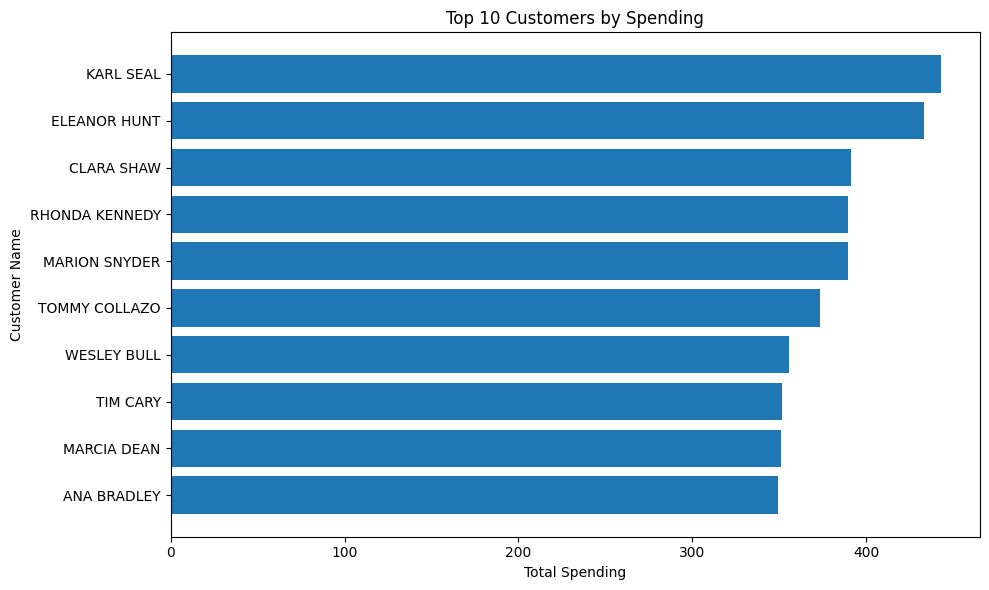

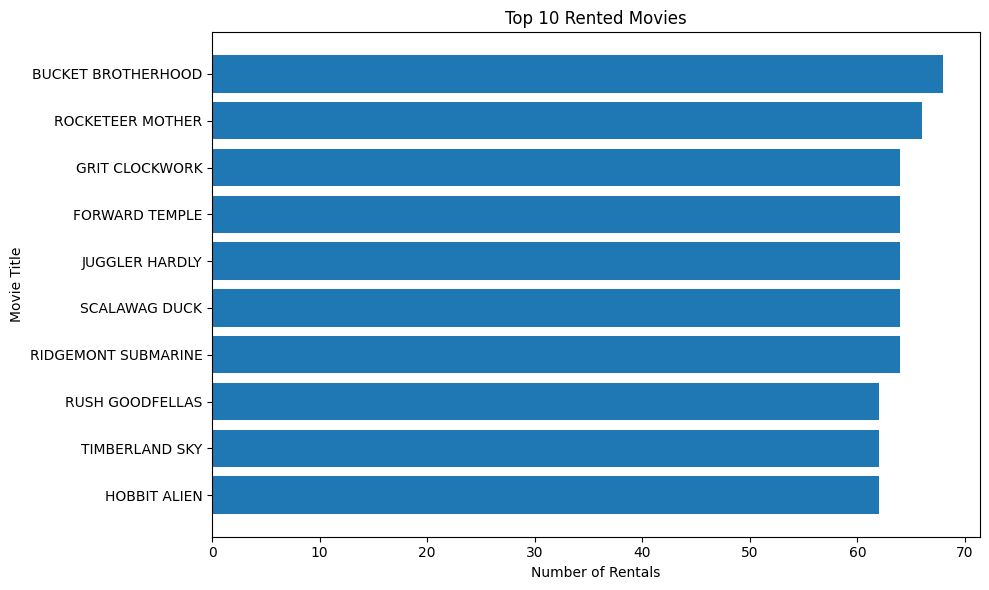


General Statistics
Total Customers: 599
Total Films: 1000
Total Stores: 2
Total Payments: 32088
Total Rentals: 32088
Total Revenue: $134813.12


In [ ]:
# Analysis and Visualizations

import pandas as pd
import matplotlib.pyplot as plt

# Top customers by spending
top_customers = pd.read_sql("""
SELECT
    dc.customer_id,
    dc.full_name,
    SUM(fp.payment_amount) AS total_spending
FROM fact_payment fp
JOIN dim_customer dc
    ON fp.customer_key = dc.customer_key
GROUP BY
    dc.customer_id,
    dc.full_name
ORDER BY total_spending DESC
LIMIT 10
""", dw_engine)

print("Top customers by spending:")
print(top_customers)


# Top rented movies
top_movies = pd.read_sql("""
SELECT
    df.title,
    SUM(fr.rental_count) AS total_rentals
FROM fact_rental fr
JOIN dim_film df
    ON fr.film_key = df.film_key
GROUP BY df.title
ORDER BY total_rentals DESC
LIMIT 10
""", dw_engine)

print("\nTop rented movies:")
print(top_movies)


# Chart 1: Top customers by spending
plt.figure(figsize=(10, 6))

top_customers_plot = top_customers.sort_values(
    "total_spending",
    ascending=True
)

plt.barh(
    top_customers_plot["full_name"],
    top_customers_plot["total_spending"]
)

plt.xlabel("Total Spending")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Spending")
plt.tight_layout()
plt.show()


# Chart 2: Top rented movies
plt.figure(figsize=(10, 6))

top_movies_plot = top_movies.sort_values(
    "total_rentals",
    ascending=True
)

plt.barh(
    top_movies_plot["title"],
    top_movies_plot["total_rentals"]
)

plt.xlabel("Number of Rentals")
plt.ylabel("Movie Title")
plt.title("Top 10 Rented Movies")
plt.tight_layout()
plt.show()


# General Statistics
print("\n" + "=" * 80)
print("General Statistics")
print("=" * 80)

total_customers = pd.read_sql(
    "SELECT COUNT(*) AS count FROM dim_customer",
    dw_engine
)
print(f"Total Customers: {total_customers['count'].values[0]}")

total_films = pd.read_sql(
    "SELECT COUNT(*) AS count FROM dim_film",
    dw_engine
)
print(f"Total Films: {total_films['count'].values[0]}")

total_stores = pd.read_sql(
    "SELECT COUNT(*) AS count FROM dim_store",
    dw_engine
)
print(f"Total Stores: {total_stores['count'].values[0]}")

total_payments = pd.read_sql(
    "SELECT COUNT(*) AS count FROM fact_payment",
    dw_engine
)
print(f"Total Payments: {total_payments['count'].values[0]}")

total_rentals = pd.read_sql(
    "SELECT COUNT(*) AS count FROM fact_rental",
    dw_engine
)
print(f"Total Rentals: {total_rentals['count'].values[0]}")

total_revenue = pd.read_sql(
    "SELECT SUM(payment_amount) AS total FROM fact_payment",
    dw_engine
)

print(f"Total Revenue: ${total_revenue['total'].values[0]:.2f}")